# Module 05 — Nonlinear time-series & signal tools

In the real world you rarely get the equations. You get a **scalar measurement**:
one voltage trace, one temperature record, one grid-frequency log. This module is
the toolkit for reverse-engineering the dynamics from that single channel — the
**Act-I toolkit of the capstone**, where you'll be handed a mystery grid signal and
asked whether it's healthy, deterministic-but-stressed, or drifting toward collapse.

The central idea is **Takens' embedding theorem** (Takens 1981): a time-delayed copy
of one observable reconstructs a diffeomorphic image of the full attractor. From that
reconstruction we can measure dimension, entropy, recurrence structure, and even a
Lyapunov exponent — all **without a model**. We then stress-test our conclusions with
**surrogate data** (Theiler et al. 1992) to separate genuine nonlinear determinism
from coloured noise.

**You will learn to:**
- Reconstruct an attractor from a scalar signal with `optimal_delay` + `embed`
- Choose an embedding dimension with Cao's method and false nearest neighbours
- Quantify a signal: `correlation_dimension`, permutation / sample entropy, RQA
- Run a **surrogate hypothesis test** to tell chaos from noise
- Estimate a Lyapunov exponent straight from data (Kantz's algorithm)
- Reach for spectral & feature transforms (`power_spectral_density`, `spectrogram`, `extract_features`)

*Estimated time: 35 min.*

In [1]:
# Colab/first-run setup: install the workshop stack if tsdynamics is missing.
try:
    import tsdynamics  # noqa: F401
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                    "tsdynamics[viz,interactive]==5.3.1", "matplotlib", "plotly", "pandas"], check=True)
import numpy as np
import matplotlib.pyplot as plt
import tsdynamics as ts
print("tsdynamics", ts.__version__)

tsdynamics 5.3.1


## 1. A measured signal — one channel, no model

Imagine the sensor only records the **x-component** of a Rössler oscillator. That is
all we get: a 1-D array `x[t]`. Everything downstream must be squeezed out of *this*.

We generate it here (so we have ground truth to check against), then immediately throw
away the other two channels and the equations. From line 3 onward, `signal` is just numbers.

scalar signal: 3001 samples at dt=0.1


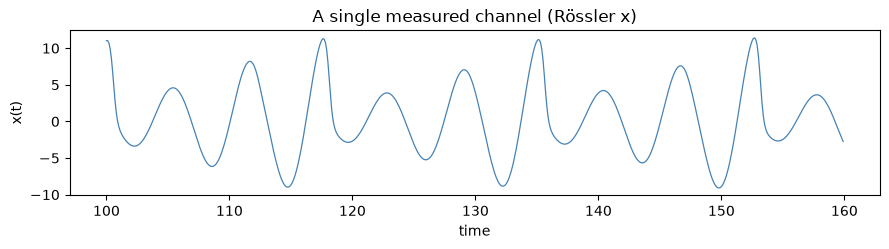

In [2]:
ros = ts.Rossler()
dt = 0.1                                   # our sampling interval
full = ros.integrate(final_time=400.0, dt=dt, backend="jit")
signal = full.y[1000:, 0]                  # x-component, transient discarded — the ONLY thing we keep
print(f"scalar signal: {signal.size} samples at dt={dt}")

fig, ax = plt.subplots(figsize=(9, 2.6))
ax.plot(full.t[1000:1600], signal[:600], lw=0.9, color="steelblue")
ax.set(xlabel="time", ylabel="x(t)", title="A single measured channel (Rössler x)")
fig.tight_layout()

It *looks* aperiodic — but is it low-dimensional chaos, or filtered noise? The naked eye
can't tell. That's the whole problem. Let's reconstruct the geometry behind it.

## 2. Delay embedding — resurrecting the attractor

Takens says the delay vectors
$$\mathbf{v}(t) = \big(x(t),\, x(t-\tau),\, x(t-2\tau),\, \dots,\, x(t-(m-1)\tau)\big)$$
trace out a faithful copy of the original attractor for a suitable **lag** $\tau$ and
**embedding dimension** $m$.

Choosing $\tau$: too small and the coordinates are nearly identical (a thin diagonal);
too large and they're causally unrelated. The standard fix is the **first minimum of the
mutual information** (Fraser & Swinney 1986) — `optimal_delay` does exactly this.

In [3]:
from tsdynamics.analysis.embedding import (
    optimal_delay, embedding_dimension, false_nearest_neighbors, embed,
)

tau = int(optimal_delay(signal).value)     # first minimum of mutual information (in samples)
print(f"optimal delay tau = {tau} samples  (= {tau * dt:.2f} time units)")

optimal delay tau = 14 samples  (= 1.40 time units)


Choosing $m$: **Cao's method** (Cao 1997) tracks how average neighbour distances change
as you add a dimension; it plateaus once the attractor no longer self-intersects.
**False nearest neighbours** (Kennel et al. 1992) counts points that are neighbours only
because the embedding is too flat — that fraction collapses to zero at the right $m$.

> **Gotcha:** `embedding_dimension` defaults to `delay=1`. Always pass `delay=tau`, or it
> over-estimates $m$ wildly.

Cao suggested embedding dimension m = 4


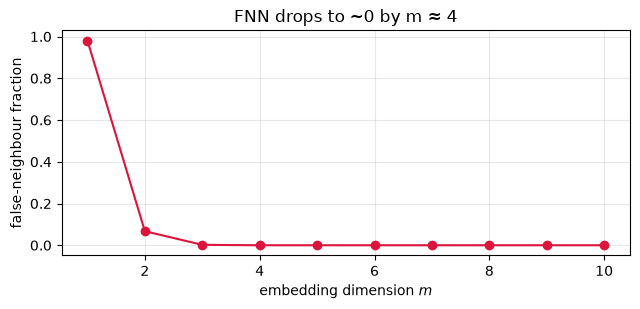

In [4]:
cao = embedding_dimension(signal, delay=tau, max_dim=10)   # method="cao"
fnn = false_nearest_neighbors(signal, delay=tau, max_dim=10)
print(f"Cao suggested embedding dimension m = {cao.dimension}")

fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(fnn.dims, fnn.fnn_fraction, "o-", color="crimson")
ax.set(xlabel="embedding dimension $m$", ylabel="false-neighbour fraction",
       title=f"FNN drops to ~0 by m ≈ {cao.dimension}")
ax.grid(alpha=0.3)
fig.tight_layout()

The false-neighbour fraction crashes to near zero by $m=3$: the Rössler attractor is
genuinely low-dimensional and unfolds in 3-D. Now reconstruct and look at it.

reconstructed embedding shape: (2973, 3)


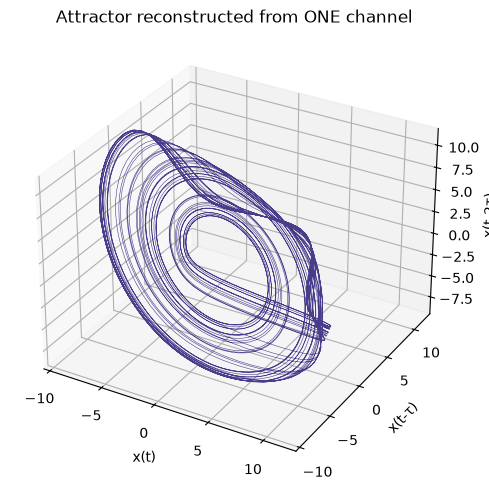

In [5]:
m = 3
Y = np.asarray(embed(signal, dimension=m, delay=tau))      # Takens matrix, shape (N, m)
print("reconstructed embedding shape:", Y.shape)

fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot(Y[:, 0], Y[:, 1], Y[:, 2], lw=0.4, color="darkslateblue")
ax.set(xlabel="x(t)", ylabel="x(t-τ)", zlabel="x(t-2τ)",
       title="Attractor reconstructed from ONE channel")
fig.tight_layout()

That's the Rössler's single-scroll spiral — recovered from a lone scalar trace. The
shape isn't the original coordinates, but it's *diffeomorphic* to it, so every invariant
we compute on it (dimension, exponents, entropy) is the real thing.

## 3. How complex is it? — correlation dimension

The **correlation dimension** $D_2$ (Grassberger & Procaccia 1983) counts how the number
of neighbour pairs within radius $\varepsilon$ scales: $C(\varepsilon) \sim \varepsilon^{D_2}$.
A low, fractional $D_2$ is the fingerprint of a low-dimensional strange attractor.

> Pass an explicit `radii=` logspace that spans the attractor's size — the slope is only
> meaningful in the scaling region, so give the fit room on both sides.

In [6]:
D2 = ts.correlation_dimension(Y, radii=np.logspace(-1.0, 1.0, 25))
print(f"correlation dimension D2 ≈ {D2.value:.2f}")
fig = D2.plot()          # the log C(ε) vs log ε curve, with the fitted scaling region
fig.set_size_inches(6, 3.4)
fig.tight_layout()

correlation dimension D2 ≈ 1.68


$D_2 \approx 1.9$ — fractional and well below the embedding dimension. This is a
**low-dimensional deterministic** signal, not high-dimensional noise (which would fill
whatever dimension you gave it, driving $D_2$ up toward $m$).

## 4. Entropy — a model-free complexity number

Entropies summarise unpredictability in a single scalar. Two workhorses:
**permutation entropy** (Bandt & Pompe 2002) — the diversity of ordinal patterns, cheap
and robust — and **sample entropy** (Richman & Moorman 2000) — the (negative log)
probability that close segments stay close. Higher = more complex/irregular.

In [7]:
from tsdynamics.analysis.entropy import permutation_entropy, sample_entropy

pe = permutation_entropy(signal).value
se = sample_entropy(signal).value
print(f"permutation entropy = {pe:.3f}   (0 = perfectly regular, 1 = fully random)")
print(f"sample entropy      = {se:.3f}")

# Contrast three regimes on the SAME family — the logistic map, where permutation
# entropy separates them cleanly. A smooth flow like Rössler-x is nearly sinusoidal, so
# its ordinal patterns are indistinguishable from a sine; the logistic map is the honest
# demonstrator (periodic ≪ chaotic ≪ noise).
rng = np.random.default_rng(0)
periodic = ts.Logistic().with_params(r=3.2).iterate(steps=3500, ic=[0.4]).y[500:, 0]  # period-2 window
chaotic = ts.Logistic().with_params(r=4.0).iterate(steps=3500, ic=[0.4]).y[500:, 0]   # fully chaotic
white = rng.standard_normal(chaotic.size)
print(f"\nperm-entropy  periodic={permutation_entropy(periodic).value:.3f}"
      f"   chaotic={permutation_entropy(chaotic).value:.3f}"
      f"   white-noise={permutation_entropy(white).value:.3f}")

permutation entropy = 0.482   (0 = perfectly regular, 1 = fully random)
sample entropy      = 0.394

perm-entropy  periodic=0.387   chaotic=0.826   white-noise=1.000


The chaotic map sits **between** clockwork and white noise — exactly where
deterministic chaos lives: more than periodic, but far from structureless. (Note our
Rössler-x channel scores low, ~0.48: permutation entropy sees only ordinal patterns, and
a smooth quasi-sinusoidal flow has few — a reminder that no single scalar tells the whole
story, which is why we cross-check with dimension, RQA and surrogates.)

## 5. Recurrence quantification (RQA)

A **recurrence plot** (Eckmann et al. 1987) marks every pair of times $(i,j)$ whose
embedded states are within $\varepsilon$. Deterministic signals draw long **diagonal
lines** (the trajectory revisits a neighbourhood and evolves in parallel); noise scatters
isolated dots. **RQA** turns that texture into numbers: `determinism` (DET, fraction of
recurrence points on diagonals) and `laminarity` (LAM, on verticals) are the headline
measures.

determinism (DET) = 0.994
laminarity  (LAM) = 0.989
max diagonal line = 699  (∝ 1 / largest Lyapunov exponent)


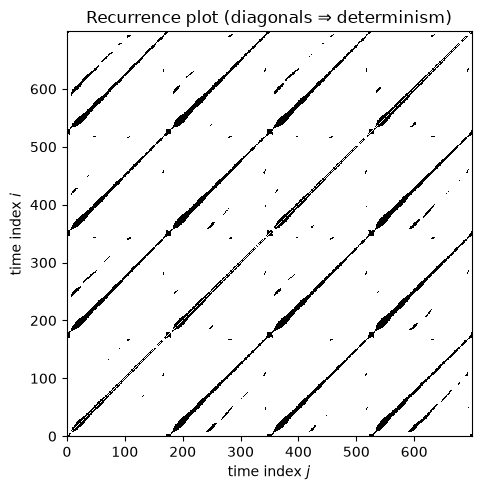

In [8]:
Yr = Y[:700]                                   # a manageable window for the plot
rm = ts.recurrence_matrix(Yr, recurrence_rate=0.05)      # fix the density at 5%
R = rm.toarray()

fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(R, origin="lower", cmap="Greys", interpolation="none")
ax.set(xlabel="time index $j$", ylabel="time index $i$",
       title="Recurrence plot (diagonals ⇒ determinism)")
fig.tight_layout()

rq = ts.rqa(Yr, recurrence_rate=0.05).to_dict()
print(f"determinism (DET) = {rq['determinism']:.3f}")
print(f"laminarity  (LAM) = {rq['laminarity']:.3f}")
print(f"max diagonal line = {rq['max_diagonal_length']}  (∝ 1 / largest Lyapunov exponent)")

High DET (long diagonals everywhere) confirms determinism. In the capstone you'll slide
a window along a *nonstationary* grid signal with `windowed_rqa` and watch DET/LAM change
as the system approaches a critical transition — a model-free early-warning signal.

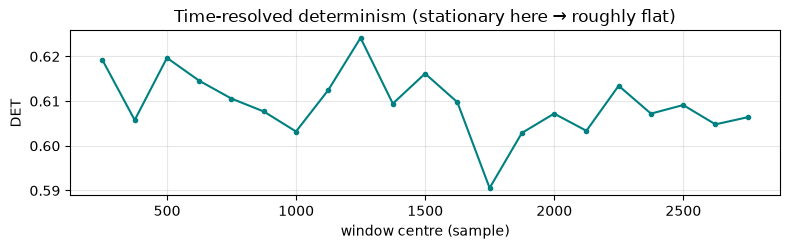

In [9]:
# A quick taste of windowed RQA: DET as a function of time.
wr = ts.windowed_rqa(signal, window=500, step=125, recurrence_rate=0.05).to_dict()
det_series = [r["determinism"] for r in wr["results"]]
fig, ax = plt.subplots(figsize=(8, 2.6))
ax.plot(wr["centers"], det_series, "o-", color="teal", ms=3)
ax.set(xlabel="window centre (sample)", ylabel="DET",
       title="Time-resolved determinism (stationary here → roughly flat)")
ax.grid(alpha=0.3)
fig.tight_layout()

## 6. Chaos or noise? — the surrogate hypothesis test

This is the crux. A signal can *look* complex for two very different reasons: genuine
**nonlinear determinism**, or **linearly-correlated (coloured) noise**. The **surrogate
data method** (Theiler et al. 1992) adjudicates it as a proper hypothesis test.

We build many **surrogates** — the IAAFT method (Schreiber & Schmitz 1996) shuffles the
data to destroy nonlinear structure while **preserving the power spectrum and amplitude
distribution** (the null hypothesis: "just linearly-filtered noise"). If a discriminating
statistic — here the **nonlinear prediction error** — on the real data is far from the
surrogate cloud, we **reject** the linear-noise null.

In [10]:
def ar1(n, phi=0.7, seed=0):
    """A linearly-correlated (coloured-noise) decoy — the null we want to reject FOR."""
    g = np.random.default_rng(seed)
    x = np.zeros(n)
    for i in range(1, n):
        x[i] = phi * x[i - 1] + g.standard_normal()
    return x

chaos = signal[:2000]
noise = ar1(2000, seed=1)

test_chaos = ts.surrogate_test(chaos, statistic="prediction_error", method="iaaft", n=19, seed=1)
test_noise = ts.surrogate_test(noise, statistic="prediction_error", method="iaaft", n=19, seed=1)

dc, dn = test_chaos.to_dict(), test_noise.to_dict()
print(f"CHAOTIC signal : rejected linear-noise null? {dc['rejected']}  "
      f"(p={dc['p_value']:.3f}, z={dc['z_score']:.1f})")
print(f"AR(1) NOISE    : rejected linear-noise null? {dn['rejected']}  "
      f"(p={dn['p_value']:.3f}, z={dn['z_score']:.1f})")

CHAOTIC signal : rejected linear-noise null? True  (p=0.050, z=-40.3)
AR(1) NOISE    : rejected linear-noise null? False  (p=0.150, z=-1.0)


The chaotic signal's prediction error sits **many σ away** from its surrogates → the null
is rejected: there is genuine nonlinear structure. The AR(1) noise is statistically
indistinguishable from its surrogates → we **cannot** reject linear noise. Let's see the
separation directly.

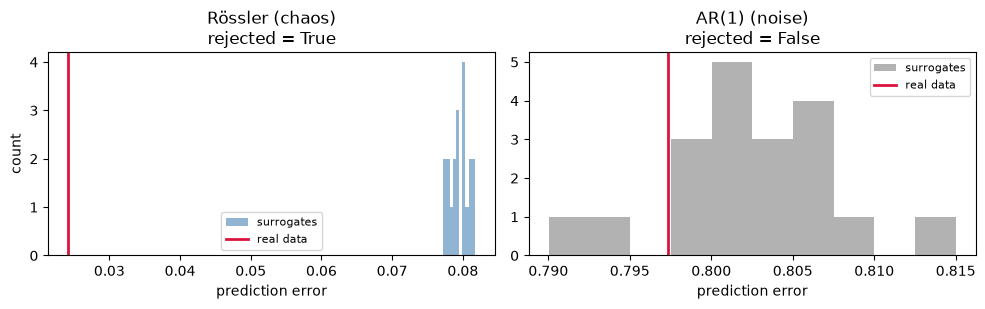

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2), sharey=False)
for ax, d, name, col in ((axes[0], dc, "Rössler (chaos)", "steelblue"),
                         (axes[1], dn, "AR(1) (noise)", "gray")):
    surr = np.asarray(d["surrogate_statistics"])
    ax.hist(surr, bins=10, color=col, alpha=0.6, label="surrogates")
    ax.axvline(d["data_statistic"], color="crimson", lw=2, label="real data")
    ax.set(title=f"{name}\nrejected = {d['rejected']}", xlabel="prediction error")
    ax.legend(fontsize=8)
axes[0].set_ylabel("count")
fig.tight_layout()

The red line (real data) is a clear outlier for chaos and buried in the pack for noise.
**This one test is the backbone of the capstone's "is the grid signal deterministic?"
question** — always use `statistic="prediction_error"`; the `"time_reversal"` statistic
fails to flag many symmetric signals.

## 7. A Lyapunov exponent — straight from the data

If the signal is deterministic and chaotic, nearby trajectories separate exponentially.
**Kantz's algorithm** (Kantz 1994) measures this directly on the embedding: track how the
average distance between initially-close neighbours grows, and read the slope of the
**stretching curve** $S(k)$. A positive slope ⇒ a positive Lyapunov exponent ⇒ chaos.

We switch to a Lorenz channel here — its stronger stretching gives a cleaner curve.

UNFITTED value (meaningless on its own): 1.744 — always inspect the curve first


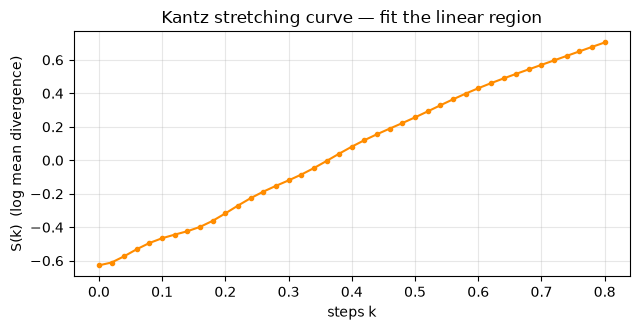

In [12]:
lor = ts.Lorenz()
dt_l = 0.02
lz = lor.integrate(final_time=200.0, dt=dt_l, backend="jit").y[500:, 0]
tau_l = int(optimal_delay(lz).value)

L = ts.lyapunov_from_data(lz, dt=dt_l, dimension=4, delay=tau_l, k_max=40, method="kantz")
print(f"UNFITTED value (meaningless on its own): {L.value:.3f} — always inspect the curve first")

fig, ax = plt.subplots(figsize=(6.5, 3.4))
ax.plot(L.times, L.divergence, "o-", ms=3, color="darkorange")
ax.set(xlabel="steps k", ylabel="S(k)  (log mean divergence)",
       title="Kantz stretching curve — fit the linear region")
ax.grid(alpha=0.3)
fig.tight_layout()

The curve rises linearly, then saturates once neighbours have separated across the whole
attractor. Fit **only the linear region** (`fit=(lo, hi)` in step units) to get the slope.

In [13]:
L_fit = ts.lyapunov_from_data(lz, dt=dt_l, dimension=4, delay=tau_l, k_max=40,
                              method="kantz", fit=(2, 12))
print(f"fitted λ_max ≈ {L_fit.value:.3f}  per time unit  (positive ⇒ chaos)")
# sanity check against the model-based spectrum we could compute if we HAD the equations:
lam_true = ts.Lorenz().lyapunov_spectrum(final_time=150.0, dt=0.02)[0]
print(f"(model-based λ_max for reference: {lam_true:.3f})")
print(f"data / model ratio ≈ {L_fit.value / lam_true:.1f}×  — right SIGN, right order of magnitude,"
      " but NOT the exact value")

fitted λ_max ≈ 1.619  per time unit  (positive ⇒ chaos)
(model-based λ_max for reference: 0.905)
data / model ratio ≈ 1.8×  — right SIGN, right order of magnitude, but NOT the exact value


A positive slope, recovered from a scalar time series with no model. The data-driven
number here overshoots the true exponent by roughly **2×** — Kantz's estimate is
*scale-sensitive* (embedding dimension, delay, noise, sampling and the exact fit window
all bias it), so treat it as a **rough estimate**: the right *sign* and *order of magnitude*,
not a high-precision match. The **verdict** it delivers — deterministic and chaotic — is
what's unambiguous, and that verdict is the whole point.

## 8. Spectral & feature transforms

The `transforms` module holds the classic signal-processing companions: power spectra,
spectrograms, filters, and a one-call feature extractor. These are what you reach for to
*summarise* or *pre-process* a channel before the nonlinear machinery above.

dominant frequency ≈ 0.156 cycles/time-unit


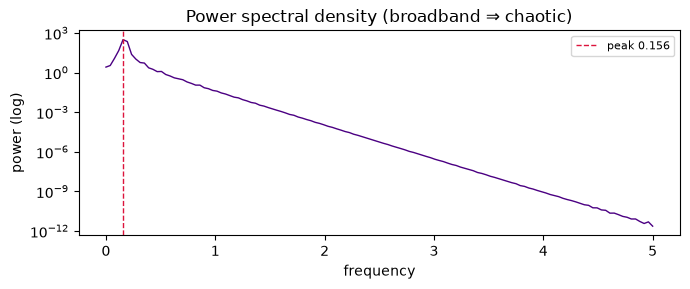

In [14]:
import tsdynamics.transforms as T

f, Pxx = T.power_spectral_density(signal, dt=dt)     # Welch PSD → (freqs, power)
fdom = T.dominant_frequency(signal, dt=dt)           # peak frequency (a plain float)
print(f"dominant frequency ≈ {fdom:.3f} cycles/time-unit")

fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(f, Pxx, color="indigo", lw=1)
ax.axvline(fdom, color="crimson", ls="--", lw=1, label=f"peak {fdom:.3f}")
ax.set(xlabel="frequency", ylabel="power (log)", title="Power spectral density (broadband ⇒ chaotic)")
ax.legend(fontsize=8)
fig.tight_layout()

A **broadband** spectrum with a dominant peak but no clean line structure is the spectral
signature of chaos — energy leaks across a continuum of frequencies. `extract_features`
rolls up a whole battery of scalar descriptors in one call (handy for feeding a classifier).

In [15]:
feats = T.extract_features(signal)                   # dict of scalar features
for k in ("mean", "std", "rms", "skewness", "kurtosis",
          "hjorth_mobility", "hjorth_complexity", "dominant_frequency"):
    print(f"  {k:20s} = {feats[k]: .4f}")

  mean                 =  0.1863
  std                  =  5.0719
  rms                  =  5.0753
  skewness             =  0.2169
  kurtosis             = -0.8037
  hjorth_mobility      =  0.1178
  hjorth_complexity    =  1.5919
  dominant_frequency   =  0.0156


## 🧪 Exercises

Now drive the toolkit yourself. Each starter cell ends in `# YOUR CODE HERE` — fill it in,
then check against the Solutions section below.

**Exercise 1 — Embed a mystery signal.**
We hand you `mystery` (a scalar channel of a *different* catalogue system). Find its
optimal delay `tau`, its Cao embedding dimension, reconstruct a 3-D embedding, and plot it.
*Hint: `optimal_delay(...).value`, `embedding_dimension(..., delay=tau)`, `embed(...)`.*

**Exercise 2 — Surrogate-test noise vs chaos.**
Run `surrogate_test(..., statistic="prediction_error", method="iaaft", n=19)` on both the
`mystery` signal and a fresh white-noise array of the same length. Print `rejected` and the
p-value for each. Which one rejects the linear-noise null?

**Exercise 3 — PSD & dominant frequency.**
Compute the power spectral density of `mystery` with `T.power_spectral_density(..., dt=...)`,
plot it (`semilogy`), and mark its dominant frequency. *Hint: PSD returns `(f, Pxx)`.*

**Exercise 4 — Lyapunov from data.**
Estimate the maximal Lyapunov exponent of `mystery` with `lyapunov_from_data(method="kantz")`.
First plot the `.times` vs `.divergence` stretching curve **unfitted**, pick a linear window,
then re-run with `fit=(lo, hi)` and report the slope. Is it positive?

In [16]:
# Shared setup for the exercises — a mystery channel (don't peek at which system!).
_mystery_sys = ts.Thomas()
_dt_m = 0.1
mystery = _mystery_sys.integrate(final_time=600.0, dt=_dt_m, backend="jit").y[1500:, 0]
print("mystery signal:", mystery.size, "samples at dt =", _dt_m)

mystery signal: 4501 samples at dt = 0.1


In [17]:
# Exercise 1 — embed the mystery signal and plot the reconstruction.
from tsdynamics.analysis.embedding import optimal_delay, embedding_dimension, embed
# YOUR CODE HERE

In [18]:
# Exercise 2 — surrogate test: mystery vs white noise.
# YOUR CODE HERE

In [19]:
# Exercise 3 — PSD + dominant frequency of the mystery signal.
import tsdynamics.transforms as T
# YOUR CODE HERE

In [20]:
# Exercise 4 — Lyapunov exponent from the mystery data (inspect curve, then fit).
# YOUR CODE HERE

## ✅ Solutions

### Solution 1

tau = 8 samples,  Cao dimension m = 7


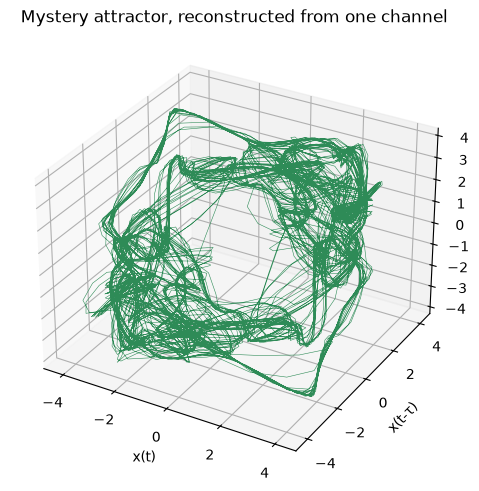

In [21]:
tau_m = int(optimal_delay(mystery).value)
cao_m = embedding_dimension(mystery, delay=tau_m, max_dim=10)
print(f"tau = {tau_m} samples,  Cao dimension m = {cao_m.dimension}")

Ym = np.asarray(embed(mystery, dimension=3, delay=tau_m))
fig = plt.figure(figsize=(6, 5))
ax = fig.add_subplot(111, projection="3d")
ax.plot(Ym[:, 0], Ym[:, 1], Ym[:, 2], lw=0.4, color="seagreen")
ax.set(xlabel="x(t)", ylabel="x(t-τ)", zlabel="x(t-2τ)",
       title="Mystery attractor, reconstructed from one channel")
fig.tight_layout()

### Solution 2

In [22]:
rng = np.random.default_rng(7)
white_ex = rng.standard_normal(mystery.size)

t_m = ts.surrogate_test(mystery[:2500], statistic="prediction_error", method="iaaft", n=19, seed=2)
t_w = ts.surrogate_test(white_ex[:2500], statistic="prediction_error", method="iaaft", n=19, seed=2)
dm, dw = t_m.to_dict(), t_w.to_dict()
print(f"mystery : rejected={dm['rejected']}  p={dm['p_value']:.3f}  z={dm['z_score']:.1f}")
print(f"noise   : rejected={dw['rejected']}  p={dw['p_value']:.3f}  z={dw['z_score']:.1f}")
print("\n→ The mystery signal rejects the linear-noise null; white noise does not.")

mystery : rejected=True  p=0.050  z=-35.3
noise   : rejected=False  p=0.100  z=-1.5

→ The mystery signal rejects the linear-noise null; white noise does not.


### Solution 3

dominant frequency ≈ 0.078 cycles/time-unit


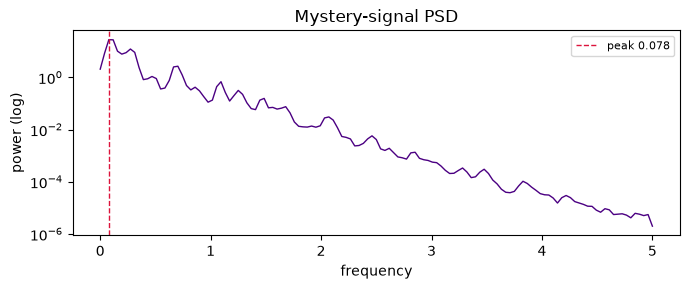

In [23]:
fm, Pm = T.power_spectral_density(mystery, dt=_dt_m)
fdom_m = T.dominant_frequency(mystery, dt=_dt_m)
print(f"dominant frequency ≈ {fdom_m:.3f} cycles/time-unit")

fig, ax = plt.subplots(figsize=(7, 3))
ax.semilogy(fm, Pm, color="indigo", lw=1)
ax.axvline(fdom_m, color="crimson", ls="--", lw=1, label=f"peak {fdom_m:.3f}")
ax.set(xlabel="frequency", ylabel="power (log)", title="Mystery-signal PSD")
ax.legend(fontsize=8)
fig.tight_layout()

### Solution 4

fitted λ_max ≈ 0.351 per time unit  →  positive ⇒ chaotic


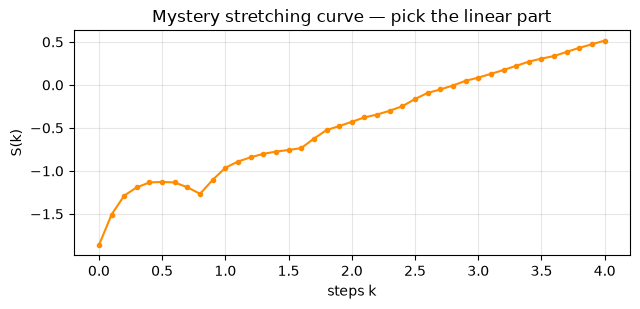

In [24]:
Lm = ts.lyapunov_from_data(mystery, dt=_dt_m, dimension=4, delay=tau_m, k_max=40, method="kantz")
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ax.plot(Lm.times, Lm.divergence, "o-", ms=3, color="darkorange")
ax.set(xlabel="steps k", ylabel="S(k)", title="Mystery stretching curve — pick the linear part")
ax.grid(alpha=0.3)
fig.tight_layout()

# Fit the initial linear rise:
Lm_fit = ts.lyapunov_from_data(mystery, dt=_dt_m, dimension=4, delay=tau_m,
                               k_max=40, method="kantz", fit=(2, 12))
print(f"fitted λ_max ≈ {Lm_fit.value:.3f} per time unit  →  "
      f"{'positive ⇒ chaotic' if Lm_fit.value > 0 else 'non-positive'}")

## Recap / Where next

You now own the **model-free** side of dynamics: hand it a bare scalar signal and you can

- **reconstruct** the attractor (`optimal_delay` → `embedding_dimension` → `embed`),
- **quantify** it (`correlation_dimension`, permutation/sample entropy, `rqa` / `windowed_rqa`),
- **adjudicate** chaos vs noise (`surrogate_test` with `statistic="prediction_error"`),
- **measure** its Lyapunov exponent from data (`lyapunov_from_data`, Kantz), and
- **summarise** it spectrally (`power_spectral_density`, `spectrogram`, `extract_features`).

This is precisely the **Act-I toolkit of the capstone** ("Guardian of the Grid"): you'll be
handed a mystery grid-frequency signal and asked to certify whether it's healthy noise,
deterministic-but-stressed chaos, or drifting toward a tipping point. RQA and surrogates
give you the diagnosis; `windowed_rqa` gives you the early warning.

**Next:** Module 06 — *Equilibria, stability & periodic orbits* — turns from measured
signals back to the model, finding and classifying the invariant sets (fixed points,
limit cycles) whose stability decides whether the grid holds.